Kaggle Dataset: https://www.kaggle.com/datasets/christopherrichardc/climate-and-flood-jakarta

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#from sklearn.preprocessing import  RobustScaler, StandardScaler, MinMaxScaler, FunctionTransformer

# Feature Selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline, FeatureUnion  # Импорт классов Pipeline и make_pipeline из scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin  # Импорт базовых классов BaseEstimator и TransformerMixin

# Metrics
from sklearn.metrics import (mean_squared_error, make_scorer, r2_score)

# Feature Selection
from sklearn.linear_model import LassoCV

# Metrics
import math


# Regression Algorithms
from lightgbm import LGBMRegressor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


In [ ]:
flood = pd.read_csv("/content/data_finish.csv")

# Displaying the first few rows of the DataFrame
flood.head()

,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,station_name,region_name,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,Stasiun Klimatologi Banten,Jakarta Selatan,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,Stasiun Klimatologi Banten,Jakarta Selatan,0


In [ ]:
flood.shape

(6308, 15)

In [ ]:
# prompt: drop station name and region name

flood = flood.drop(['station_name', 'region_name'], axis=1)
flood.head()


,date,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,flood
0,2016-01-01,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,S,96733,0
1,2016-01-02,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,W,96733,1
2,2016-01-03,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,SW,96733,1
3,2016-01-04,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,S,96733,0
4,2016-01-05,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,S,96733,0


In [ ]:
flood['ddd_car'].unique()

array(['S ', 'W ', 'SW', 'E ', 'SE', 'NE', 'C ', 'N ', 'NW', nan],
      dtype=object)

In [ ]:
# prompt: if ddd_car value equal to E  or N  then replace it with E and N respectively

flood['ddd_car'] = flood['ddd_car'].replace({'E ': 'E', 'N ': 'N','S ':'S','W ':'W'})


In [ ]:
flood = flood[flood['ddd_car'] != 'C ']


In [ ]:
# prompt: if null or nan values in ddd_car, drop the entire row

flood.dropna(subset=['ddd_car'], inplace=True)


In [ ]:
flood['ddd_car'].unique()

array(['S', 'W', 'SW', 'E', 'SE', 'NE', 'N', 'NW'], dtype=object)

In [ ]:
# prompt: count the amount of NaN values in ddd_car

flood['ddd_car'].isna().sum()


0

In [ ]:
# prompt: map ddd_car  values into numerical values

flood['ddd_car'] = flood['ddd_car'].map({'S': 1, 'W': 2, 'SW': 3,'E':4,'SE':5,'NE':6,'N':7, 'NW': 8})

In [ ]:
flood.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4968 entries, 0 to 6307
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        4968 non-null   object 
 1   Tn          4710 non-null   float64
 2   Tx          4774 non-null   float64
 3   Tavg        4929 non-null   float64
 4   RH_avg      4924 non-null   float64
 5   RR          3078 non-null   float64
 6   ss          3829 non-null   float64
 7   ff_x        4964 non-null   float64
 8   ddd_x       4964 non-null   float64
 9   ff_avg      4899 non-null   float64
 10  ddd_car     4968 non-null   int64  
 11  station_id  4968 non-null   int64  
 12  flood       4968 non-null   int64  
dtypes: float64(9), int64(3), object(1)
memory usage: 543.4+ KB


In [ ]:
# prompt: drop date column

flood = flood.drop('date', axis=1)
flood.head()


,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,station_id,flood
0,26.0,34.8,28.6,81.0,NaN,5.8,5.0,280.0,2.0,1,96733,0
1,25.6,33.2,27.0,88.0,1.6,8.7,4.0,290.0,2.0,2,96733,1
2,24.4,34.9,28.1,80.0,33.8,5.4,4.0,280.0,2.0,3,96733,1
3,24.8,33.6,29.2,81.0,NaN,6.6,3.0,200.0,1.0,1,96733,0
4,25.8,33.6,26.7,91.0,NaN,3.2,3.0,180.0,1.0,1,96733,0


In [ ]:
# prompt: calculate the average of each column, replace missing values in each column with that average

for column in flood.columns:
  average = flood[column].mean()
  flood[column].fillna(average, inplace=True)


In [ ]:
# prompt: drop station id

flood = flood.drop('station_id', axis=1)
flood.head()


,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,flood
0,26.0,34.8,28.6,81.0,9.224691,5.8,5.0,280.0,2.0,1,0
1,25.6,33.2,27.0,88.0,1.600000,8.7,4.0,290.0,2.0,2,1
2,24.4,34.9,28.1,80.0,33.800000,5.4,4.0,280.0,2.0,3,1
3,24.8,33.6,29.2,81.0,9.224691,6.6,3.0,200.0,1.0,1,0
4,25.8,33.6,26.7,91.0,9.224691,3.2,3.0,180.0,1.0,1,0


In [ ]:
# prompt: count how many null in dataframe

flood.isnull().sum().sum()


0

In [ ]:
summary_stat = flood.describe().round(2)
print(summary_stat)

            Tn       Tx     Tavg   RH_avg       RR       ss     ff_x    ddd_x  \
count  4968.00  4968.00  4968.00  4968.00  4968.00  4968.00  4968.00  4968.00   
mean     25.37    32.60    28.30    76.87     9.22     4.93     5.14   190.37   
std       3.48     6.13     1.94    10.30    13.55     2.48     6.53   109.10   
min       2.40    21.30    23.70    34.00     0.00     0.00     0.00     0.00   
25%      24.20    31.80    27.60    72.00     0.40     3.50     4.00    80.00   
50%      25.00    32.60    28.40    77.00     9.22     4.93     4.00   230.00   
75%      26.00    33.40    29.00    81.00     9.22     6.50     6.00   280.00   
max     246.00   334.00   141.60   488.00   179.70    11.60   185.00   360.00   

        ff_avg  ddd_car    flood  
count  4968.00  4968.00  4968.00  
mean      2.57     4.63     0.07  
std       1.63     2.26     0.26  
min       0.00     1.00     0.00  
25%       2.00     2.00     0.00  
50%       2.00     5.00     0.00  
75%       3.00     7.00  

In [ ]:

Q1 = flood.quantile(0.25)
Q3 = flood.quantile(0.75)
IQR = Q3 - Q1
flood_copy = flood[~((flood < (Q1 - 1.5 * IQR)) |(flood > (Q3 + 1.5 * IQR))).any(axis=1)]


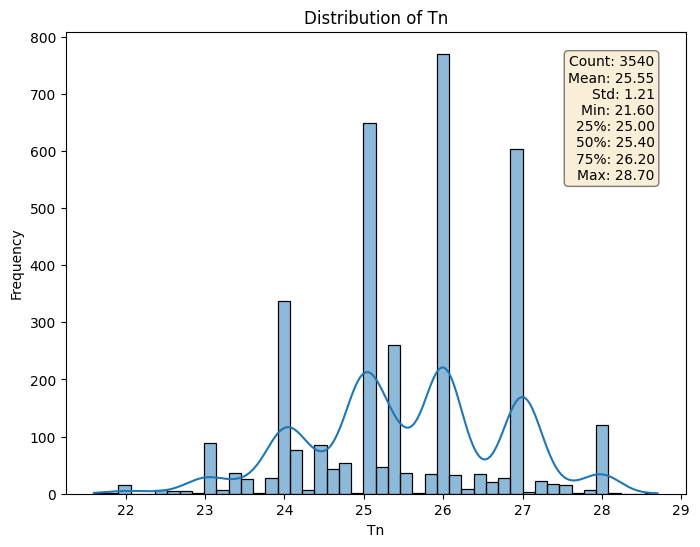

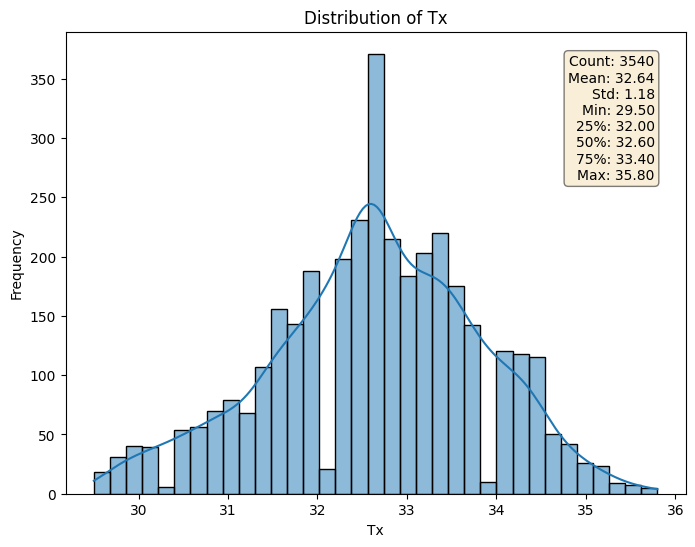

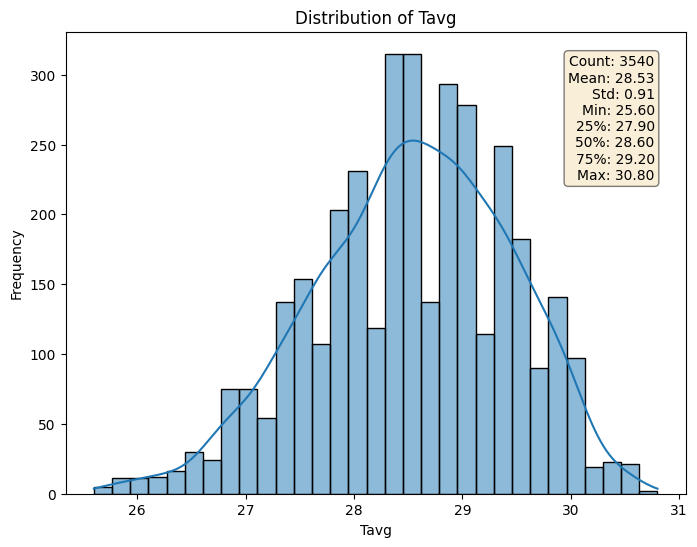

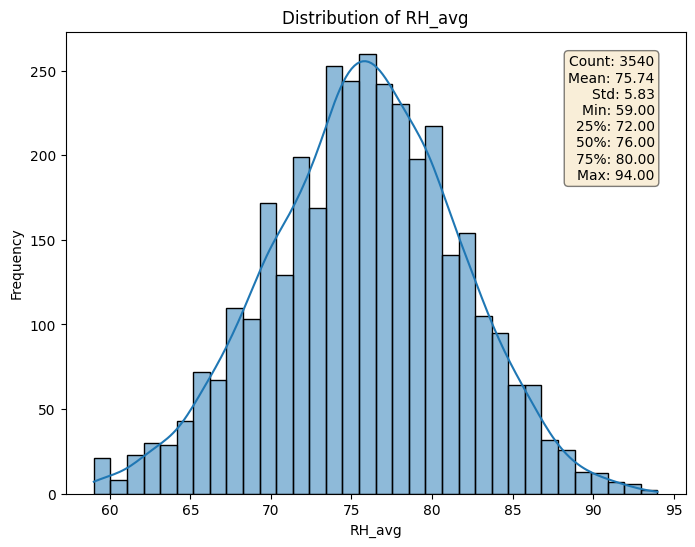

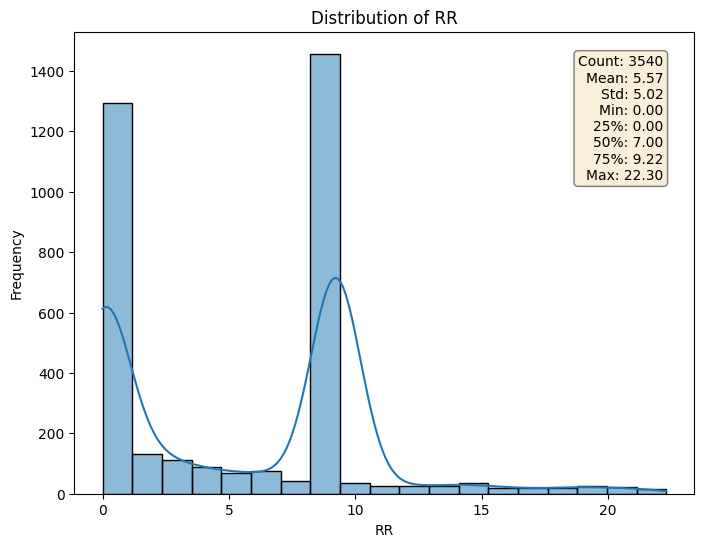

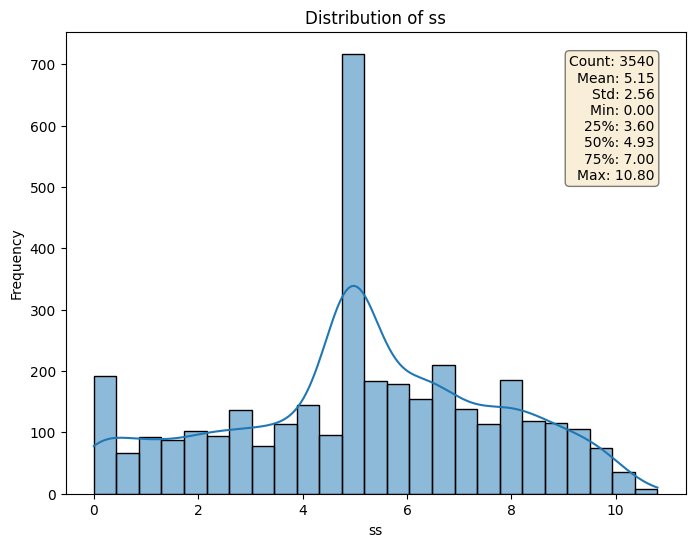

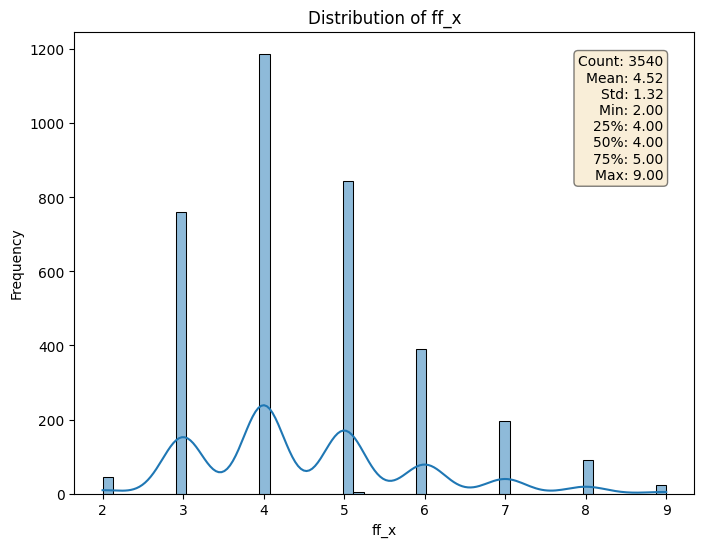

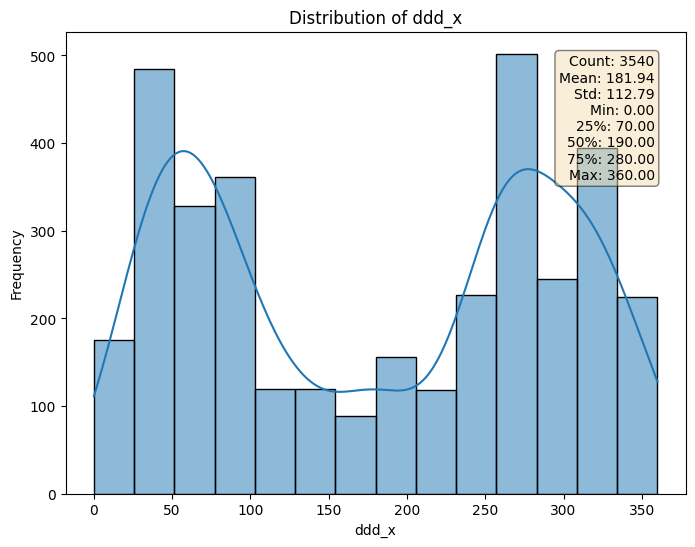

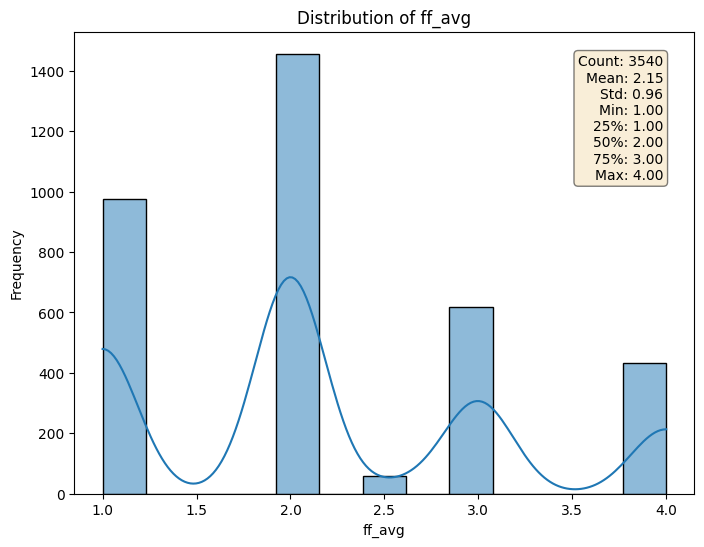

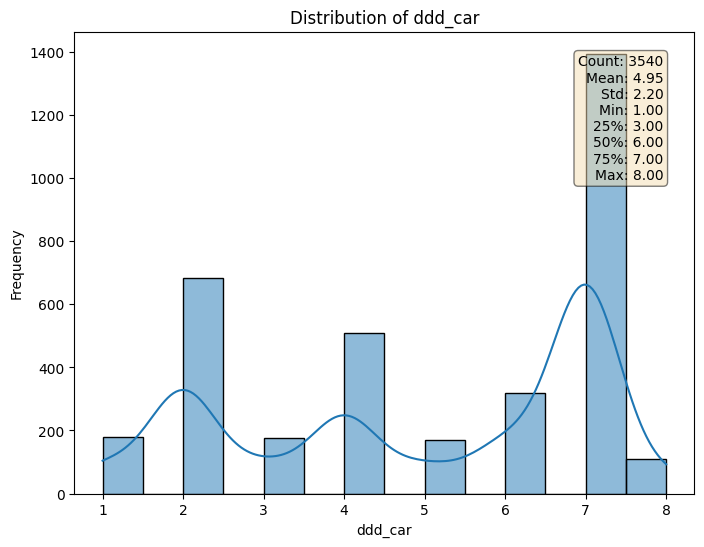

In [ ]:

# Select columns for histograms (excluding specified columns)
columns_for_hist = [col for col in flood_copy.columns if col not in ['flood']]

# Create histograms with summary statistics
for col in columns_for_hist:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.histplot(flood_copy[col], kde=True, ax=ax)

    # Calculate summary statistics
    summary = flood_copy[col].describe()

    # Add summary statistics as text within the plot
    textstr = '\n'.join((
        f"Count: {summary['count']:.0f}",
        f"Mean: {summary['mean']:.2f}",
        f"Std: {summary['std']:.2f}",
        f"Min: {summary['min']:.2f}",
        f"25%: {summary['25%']:.2f}",
        f"50%: {summary['50%']:.2f}",
        f"75%: {summary['75%']:.2f}",
        f"Max: {summary['max']:.2f}"
    ))

    # Position the text within the plot (adjust as needed)
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


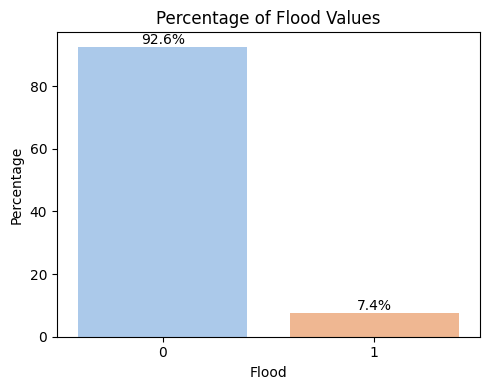

In [ ]:

# Calculate percentage of 0 and 1
flood_counts = flood['flood'].value_counts(normalize=True) * 100

# Create bar plot
plt.figure(figsize=(5, 4))  # Adjust figure size as needed
ax = sns.barplot(x=flood_counts.index, y=flood_counts.values, palette="pastel")
plt.xlabel('Flood')
plt.ylabel('Percentage')
plt.title('Percentage of Flood Values')

# Add percentage values on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()


In [ ]:
variance = floodc.var()
mean = floodc.mean()
std_dev = floodc.std()
cv = (std_dev / mean) * 100

# Classify dispersion
def classify_dispersion(cv_value):
    if cv_value < 25:
        return 'low'
    elif 25 <= cv_value < 50:
        return 'moderate'
    else:
        return 'high'

dispersion = cv.apply(classify_dispersion)

# Create a DataFrame with statistics
statistics = pd.DataFrame({
    'Variance': variance,
    'Coefficient of Variation (%)': cv,
    'Dispersion': dispersion
})
print(statistics)

             Variance  Coefficient of Variation (%) Dispersion
Tn          12.143768                     13.735436        low
Tx          37.585298                     18.804477        low
Tavg         3.772017                      6.862632        low
RH_avg     106.159227                     13.403329        low
RR         183.618454                    146.894765       high
ss           6.141248                     50.263010       high
ff_x        42.702608                    127.119547       high
ddd_x    11902.455254                     57.309486       high
ff_avg       2.666217                     63.476895       high
ddd_car      5.102272                     48.746025   moderate


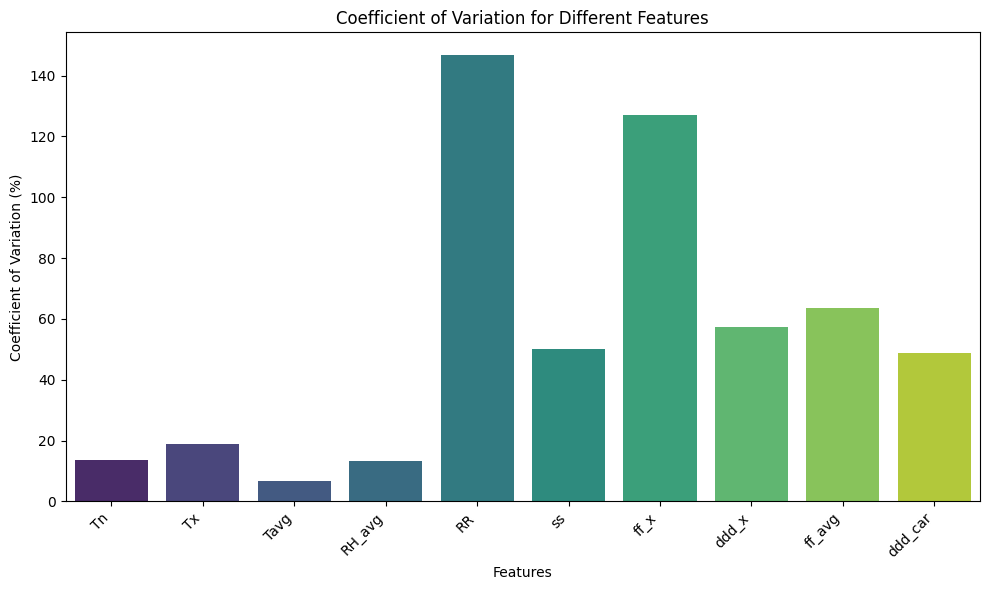

In [ ]:

# Create a bar plot for Coefficient of Variation
plt.figure(figsize=(10, 6))
sns.barplot(x=statistics.index, y=statistics['Coefficient of Variation (%)'], palette="viridis")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.xlabel('Features')
plt.ylabel('Coefficient of Variation (%)')
plt.title('Coefficient of Variation for Different Features')
plt.tight_layout()
plt.show()


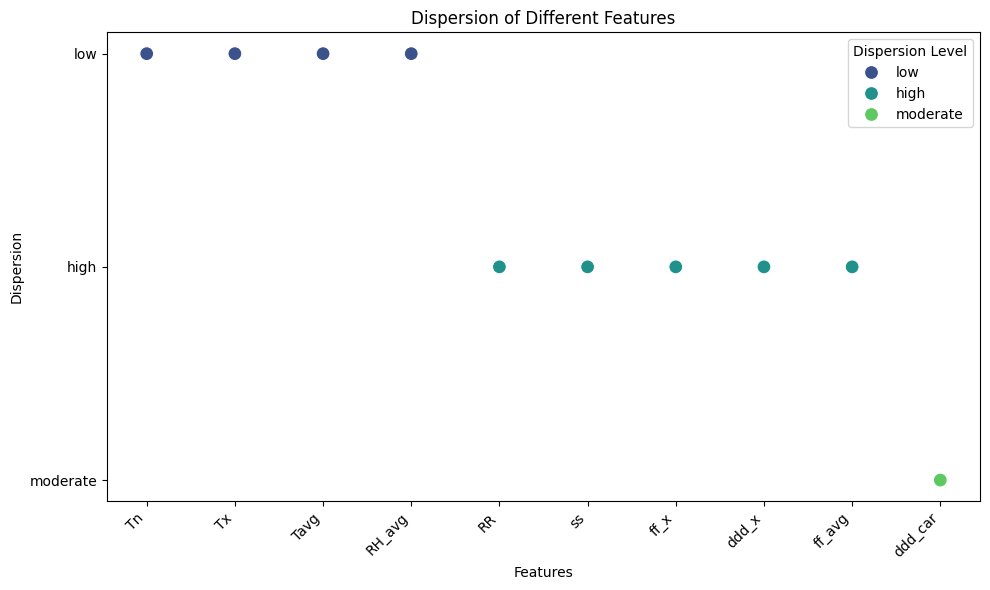

In [ ]:

# Create a scatter plot for Dispersion
plt.figure(figsize=(10, 6))
sns.scatterplot(x=statistics.index, y=statistics['Dispersion'], s=100, hue=statistics['Dispersion'], palette="viridis")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.xlabel('Features')
plt.ylabel('Dispersion')
plt.title('Dispersion of Different Features')
plt.tight_layout()
plt.legend(title='Dispersion Level')
plt.show()


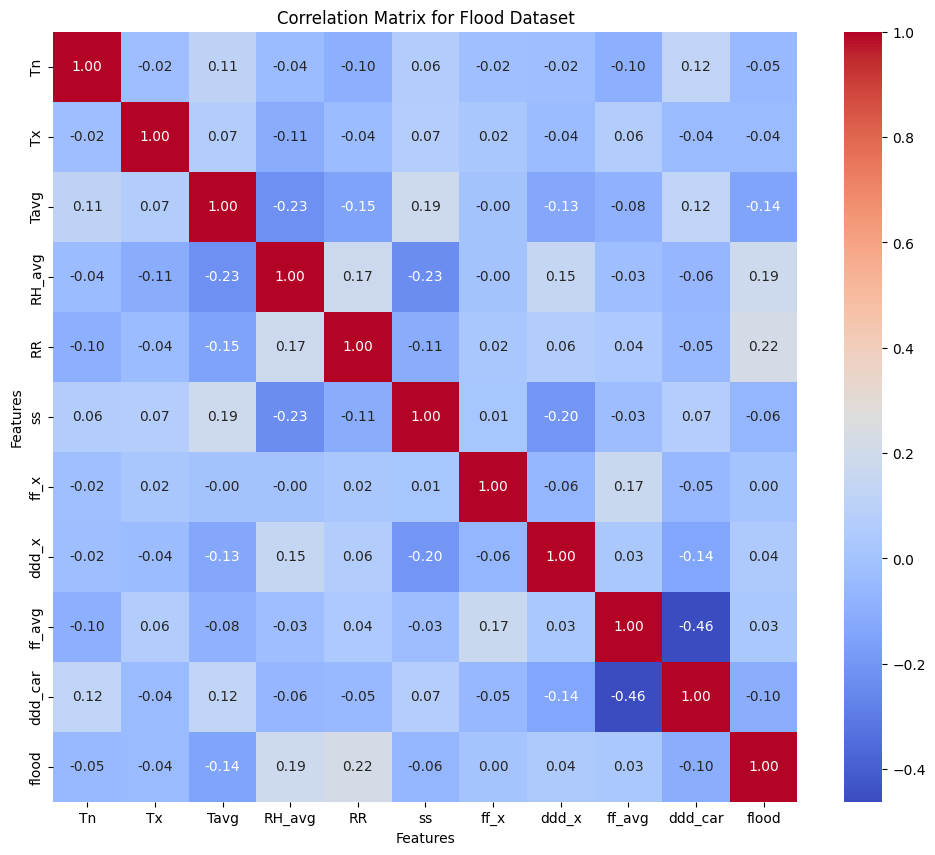

In [ ]:
# Calculate the correlation matrix
correlation_matrix = flood.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Flood Dataset')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [ ]:
!pip install plotly


In [ ]:
flood

,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,flood
0,26.0,34.8,28.6,81.0,9.224691,5.800000,5.0,280.0,2.0,1,0
1,25.6,33.2,27.0,88.0,1.600000,8.700000,4.0,290.0,2.0,2,1
2,24.4,34.9,28.1,80.0,33.800000,5.400000,4.0,280.0,2.0,3,1
3,24.8,33.6,29.2,81.0,9.224691,6.600000,3.0,200.0,1.0,1,0
4,25.8,33.6,26.7,91.0,9.224691,3.200000,3.0,180.0,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6303,23.8,32.0,28.0,70.0,9.224691,4.930373,12.0,180.0,5.0,2,0
6304,24.0,33.4,28.5,69.0,9.224691,4.930373,14.0,250.0,3.0,5,0
6305,25.2,33.4,28.7,70.0,9.224691,4.930373,14.0,120.0,5.0,3,0
6306,24.0,34.4,30.0,64.0,9.224691,4.930373,14.0,240.0,5.0,2,0


In [ ]:

flood['flood'].value_counts()


,count
flood,
0,4598
1,370


In [ ]:
flood

,Tn,Tx,Tavg,RH_avg,RR,ss,ff_x,ddd_x,ff_avg,ddd_car,flood
0,26.0,34.8,28.6,81.0,9.224691,5.800000,5.0,280.0,2.0,1,0
1,25.6,33.2,27.0,88.0,1.600000,8.700000,4.0,290.0,2.0,2,1
2,24.4,34.9,28.1,80.0,33.800000,5.400000,4.0,280.0,2.0,3,1
3,24.8,33.6,29.2,81.0,9.224691,6.600000,3.0,200.0,1.0,1,0
4,25.8,33.6,26.7,91.0,9.224691,3.200000,3.0,180.0,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6303,23.8,32.0,28.0,70.0,9.224691,4.930373,12.0,180.0,5.0,2,0
6304,24.0,33.4,28.5,69.0,9.224691,4.930373,14.0,250.0,3.0,5,0
6305,25.2,33.4,28.7,70.0,9.224691,4.930373,14.0,120.0,5.0,3,0
6306,24.0,34.4,30.0,64.0,9.224691,4.930373,14.0,240.0,5.0,2,0


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create a Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Fit the model to the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9864130434782609


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9734888653234358
Recall: 1.0
F1-score: 0.9865663621708759


In [ ]:

from sklearn.metrics import confusion_matrix


Confusion Matrix:
[[897  25]
 [  0 918]]


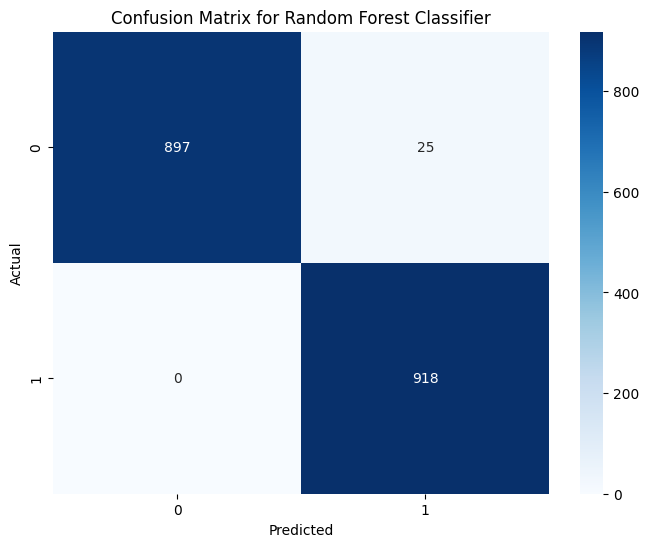

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()


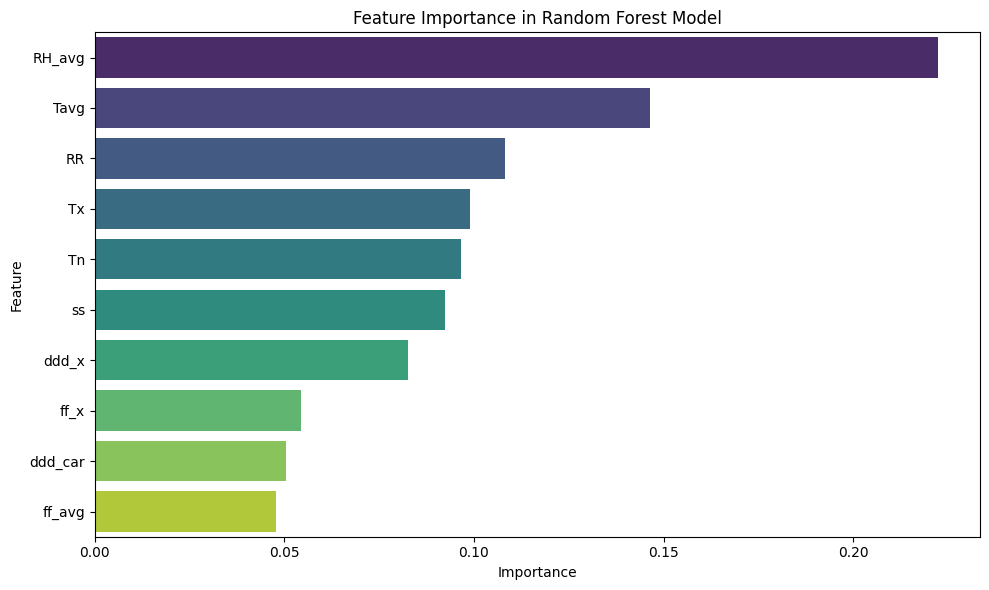

In [ ]:
# prompt: Create aesthetic plot with colors for feature importance of random forest model.

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a DataFrame for feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the DataFrame by importance in descending order
feature_importances = feature_importances.sort_values('Importance', ascending=False)

# Create a bar plot for feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Model')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create an SVM classifier
svm_classifier = SVC(kernel='rbf', random_state=42)  # You can try different kernels like 'linear', 'poly', etc.

# Fit the model to the training data
svm_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = svm_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.7353260869565217
Precision: 0.7391786903440621
Recall: 0.7254901960784313
F1-score: 0.7322704782847719


Confusion Matrix:
[[687 235]
 [252 666]]


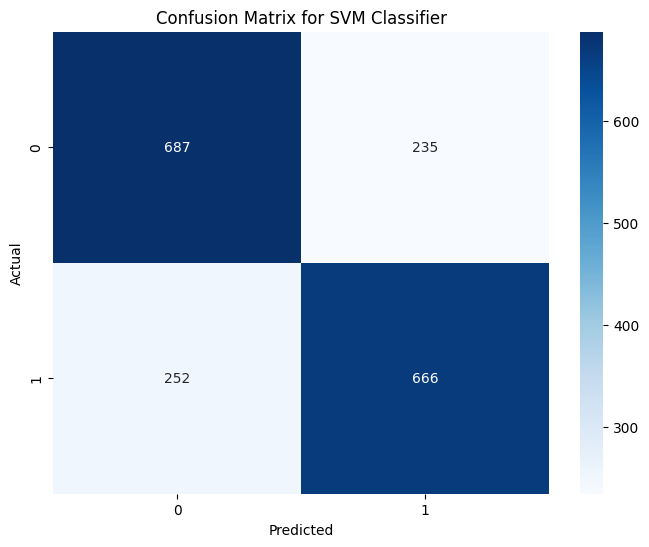

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create an MLP classifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42)

# Fit the model to the training data
mlp_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = mlp_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.7684782608695652
Precision: 0.8022113022113022
Recall: 0.7113289760348583
F1-score: 0.7540415704387989


Confusion Matrix:
[[761 161]
 [265 653]]


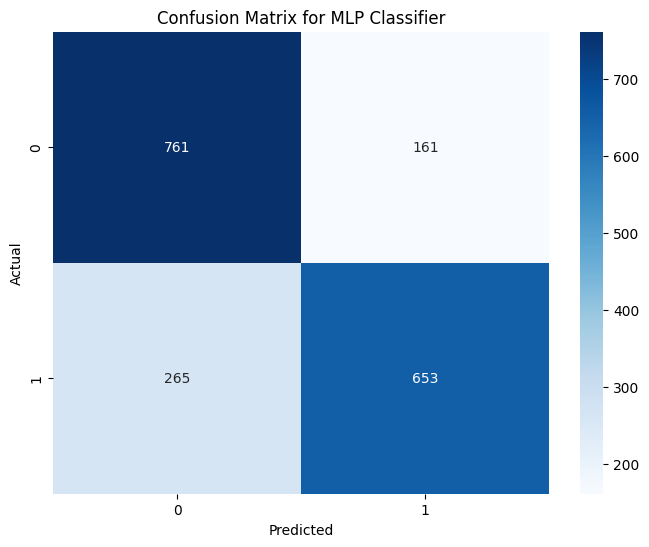

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for MLP Classifier')
plt.show()

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create a KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors (n_neighbors)

# Fit the model to the training data
knn_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = knn_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.907608695652174
Precision: 0.84375
Recall: 1.0
F1-score: 0.9152542372881356


Confusion Matrix:
[[752 170]
 [  0 918]]


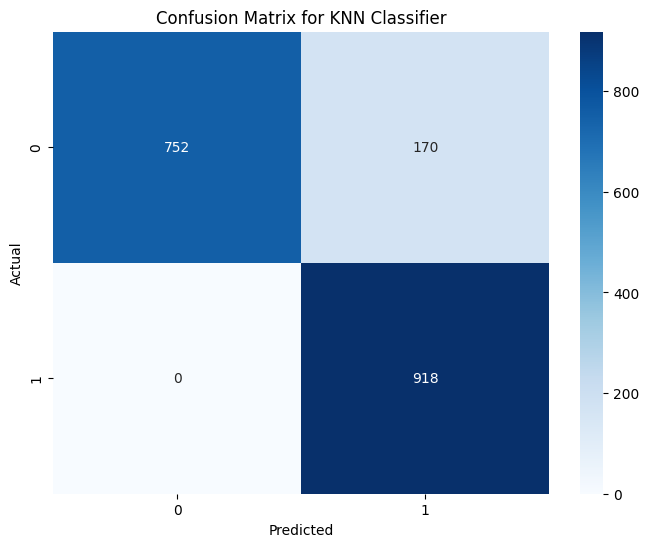

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Classifier')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create an XGBoost classifier
xgb_classifier = XGBClassifier(random_state=42)

# Fit the model to the training data
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9630434782608696
Precision: 0.9310344827586207
Recall: 1.0
F1-score: 0.9642857142857143


Confusion Matrix:
[[854  68]
 [  0 918]]


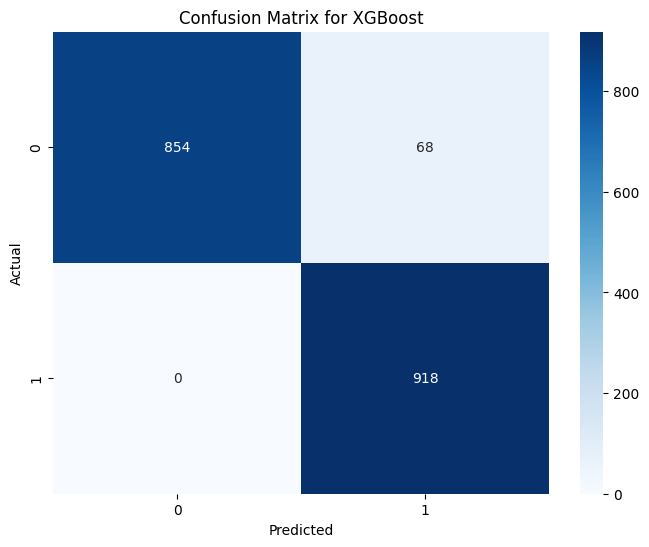

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost')
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create a Logistic Regression classifier
logreg_classifier = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

# Fit the model to the training data
logreg_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = logreg_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.7369565217391304
Precision: 0.739514348785872
Recall: 0.7298474945533769
F1-score: 0.7346491228070176


Confusion Matrix:
[[686 236]
 [248 670]]


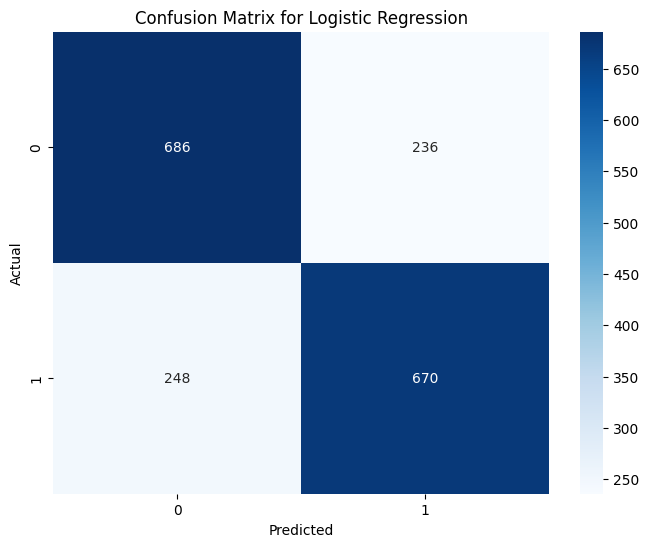

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Separate features and target variable
X = flood.drop('flood', axis=1)
y = flood['flood']

# Apply Random Oversampling
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Create a Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()

# Fit the model to the training data
nb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = nb_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Accuracy: 0.6809782608695653
Precision: 0.6394271272114574
Recall: 0.826797385620915
F1-score: 0.7211401425178147


Confusion Matrix:
[[494 428]
 [159 759]]


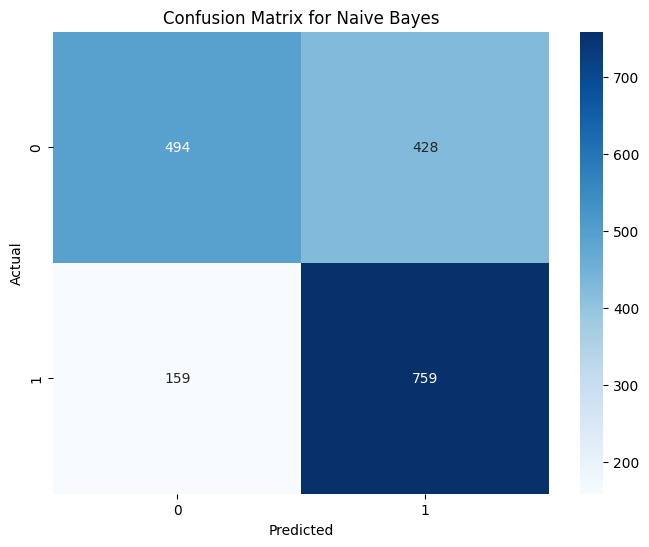

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from tabulate import tabulate

# Assuming you have already trained and evaluated your models as shown in the previous code

# Create a list of model names and their corresponding metrics
model_results = [
    ["Random Forest", accuracy_score(y_test, rf_classifier.predict(X_test)), precision_score(y_test, rf_classifier.predict(X_test)), recall_score(y_test, rf_classifier.predict(X_test)), f1_score(y_test, rf_classifier.predict(X_test))],
    ["SVM", accuracy_score(y_test, svm_classifier.predict(X_test)), precision_score(y_test, svm_classifier.predict(X_test)), recall_score(y_test, svm_classifier.predict(X_test)), f1_score(y_test, svm_classifier.predict(X_test))],
    ["MLP", accuracy_score(y_test, mlp_classifier.predict(X_test)), precision_score(y_test, mlp_classifier.predict(X_test)), recall_score(y_test, mlp_classifier.predict(X_test)), f1_score(y_test, mlp_classifier.predict(X_test))],
    ["KNN", accuracy_score(y_test, knn_classifier.predict(X_test)), precision_score(y_test, knn_classifier.predict(X_test)), recall_score(y_test, knn_classifier.predict(X_test)), f1_score(y_test, knn_classifier.predict(X_test))],
    ["XGBoost", accuracy_score(y_test, xgb_classifier.predict(X_test)), precision_score(y_test, xgb_classifier.predict(X_test)), recall_score(y_test, xgb_classifier.predict(X_test)), f1_score(y_test, xgb_classifier.predict(X_test))],
    ["Logistic Regression", accuracy_score(y_test, logreg_classifier.predict(X_test)), precision_score(y_test, logreg_classifier.predict(X_test)), recall_score(y_test, logreg_classifier.predict(X_test)), f1_score(y_test, logreg_classifier.predict(X_test))],
    ["Gaussian Naive Bayes", accuracy_score(y_test, nb_classifier.predict(X_test)), precision_score(y_test, nb_classifier.predict(X_test)), recall_score(y_test, nb_classifier.predict(X_test)), f1_score(y_test, nb_classifier.predict(X_test))]
]

# Sort the results by accuracy in descending order
model_results.sort(key=lambda x: x[1], reverse=True)

# Create a table using tabulate
table_headers = ["Model", "Accuracy", "Precision", "Recall", "F1-score"]
table = tabulate(model_results, headers=table_headers, tablefmt="grid")

# Print the table
print(table)

+----------------------+------------+-------------+----------+------------+
| Model                |   Accuracy |   Precision |   Recall |   F1-score |
+======================+============+=============+==========+============+
| Random Forest        |   0.986413 |    0.973489 | 1        |   0.986566 |
+----------------------+------------+-------------+----------+------------+
| XGBoost              |   0.963043 |    0.931034 | 1        |   0.964286 |
+----------------------+------------+-------------+----------+------------+
| KNN                  |   0.907609 |    0.84375  | 1        |   0.915254 |
+----------------------+------------+-------------+----------+------------+
| MLP                  |   0.768478 |    0.802211 | 0.711329 |   0.754042 |
+----------------------+------------+-------------+----------+------------+
| Logistic Regression  |   0.736957 |    0.739514 | 0.729847 |   0.734649 |
+----------------------+------------+-------------+----------+------------+
| SVM       